In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
# 1. Load dataset
# wdbc.data does not have headers, so we define them
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("Dataset/wdbc.data", header=None, names=columns)

In [6]:
# 2. Prepare features and target
X = data.drop(["ID", "Diagnosis"], axis=1)
y = data["Diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 4. Pipeline with PCA
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("clf", AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                               random_state=42))
])

In [9]:
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.1, 1.0],
    "clf__estimator__max_depth": [1, 2]
}

In [10]:
# 5. Hyperparameter grid
param_grid = {
    "pca__n_components": [5, 10, 15],  # number of PCA components
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.1, 1.0],
    "clf__estimator__max_depth": [1, 2]
}

In [11]:
# 6. GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1": "f1_macro"},
    refit="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('clf',
                                        AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__estimator__max_depth': [1, 2],
                         'clf__learning_rate': [0.01, 0.1, 1.0],
                         'clf__n_estimators': [50, 100, 200],
                         'pca__n_components': [5, 10, 15]},
             refit='accuracy',
             scoring={'accuracy': 'accuracy', 'f1': 'f1_macro'}, verbose=1)

In [12]:
print("Best Hyperparameters (with PCA):", grid.best_params_)
print("Accuracy:",grid.best_score_)

Best Hyperparameters (with PCA): {'clf__estimator__max_depth': 2, 'clf__learning_rate': 1.0, 'clf__n_estimators': 200, 'pca__n_components': 15}
Accuracy: 0.9758241758241759


In [13]:
# 1. Prepare the table (select useful columns from results)
table = results[[
    "param_clf__n_estimators",
    "param_clf__learning_rate",
    "param_clf__estimator__max_depth",
    "mean_test_accuracy",
    "mean_test_f1"
]].copy()

# 2. Rename columns for readability
table = table.rename(columns={
    "param_clf__n_estimators": "n_estimators",
    "param_clf__learning_rate": "learning_rate",
    "param_clf__estimator__max_depth": "max_depth",
    "mean_test_accuracy": "Accuracy",
    "mean_test_f1": "F1_score"
})

# 3. Sort by Accuracy (descending)
table = table.sort_values(by="Accuracy", ascending=False)

# 4. Select the best hyperparameters (row with highest Accuracy)
best_row = table.iloc[[0]]

# 5. Select 4 other strong configurations (next 4 best)
other_rows = table.iloc[1:5]

# 6. Combine best + 4
final_table = pd.concat([best_row, other_rows]).reset_index(drop=True)

# 7. Display
print("Table: AdaBoost - Best + 4 Good Hyperparameters (with PCA)")
print(final_table)


NameError: name 'results' is not defined

In [ ]:
# 7. Best model evaluation
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Test Accuracy:", acc)
print("Test F1 Score:", f1)

Test Accuracy: 0.9736842105263158
Test F1 Score: 0.963855421686747


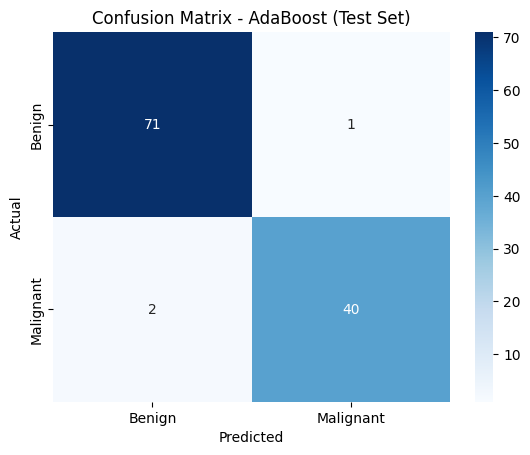

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AdaBoost (Test Set)")
plt.show()

/tmp/ipykernel_10427/1424558563.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="coolwarm")


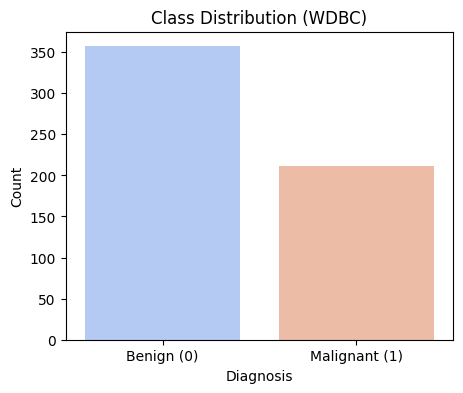

/tmp/ipykernel_10427/1424558563.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette="viridis")


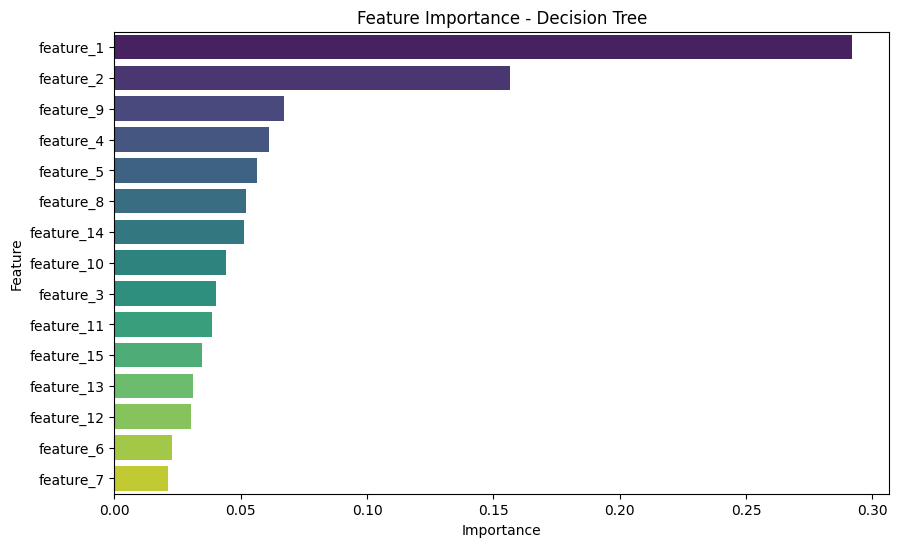

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ---- Class distribution ----
plt.figure(figsize=(5,4))
sns.countplot(x=y, palette="coolwarm")
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.title("Class Distribution (WDBC)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# ---- Feature importance (from Decision Tree) ----
best_clf = best_model.named_steps["clf"]
importances = best_clf.feature_importances_
features = X.columns

# Sort feature importances
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features[indices], palette="viridis")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Best AdaBoost model from GridSearch
best_ab = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=grid.best_params_['clf__estimator__max_depth'],
                                     random_state=42),
    n_estimators=grid.best_params_['clf__n_estimators'],
    learning_rate=grid.best_params_['clf__learning_rate'],
    random_state=42
)

# Pipeline with scaling
pipe_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_ab)
])

# 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring="accuracy")


# Print each fold accuracy and average
for i, acc in enumerate(cv_acc, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")
print(f"Average 5-Fold CV Accuracy: {cv_acc.mean():.4f}")


Fold 1 Accuracy: 0.9670
Fold 2 Accuracy: 0.9890
Fold 3 Accuracy: 0.9560
Fold 4 Accuracy: 0.9670
Fold 5 Accuracy: 0.9890
Average 5-Fold CV Accuracy: 0.9736
